In [1]:
!pip install nltk

In [ ]:
import nltk
# url -> https://mitu.co.in/dataset
# data -> SMSSpamCollection

In [26]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/aditya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/aditya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/aditya/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [27]:
import pandas as pd
import seaborn as sns


In [28]:
df = pd.read_csv("SMSSpamCollection", sep = '\t', names = ['label', 'text'])

In [29]:
df
""" 
separate input and output
check the target variable disrtibution
""";

In [30]:
x = df['text']
y = df['label']

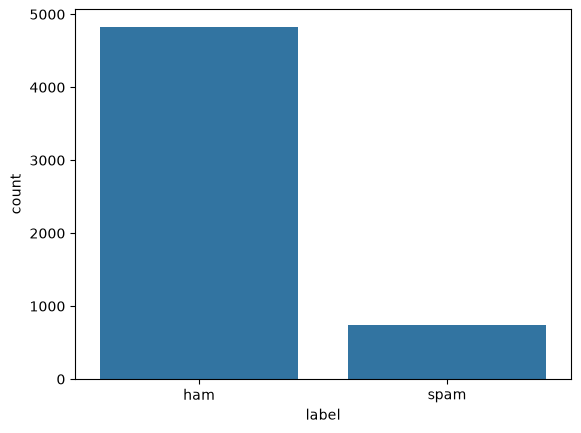

In [31]:
sns.countplot(x = y);

In [32]:
""" 
data preprocessing =>

tokenization
remove punctuation
remove stopwords
remove suffixes -> root word
convert data to numbers/vectors
""";

In [33]:
sent = 'Hello friends! How are you? I like Python Programming'

In [34]:
# tokenize

In [35]:
from nltk.tokenize import word_tokenize

In [36]:
tokens1 = word_tokenize(sent)

In [37]:
# nltk.download('punkt_tab')

In [38]:
tokens1

['Hello',
 'friends',
 '!',
 'How',
 'are',
 'you',
 '?',
 'I',
 'like',
 'Python',
 'Programming']

In [39]:
# remove punctuation and numbers and make everything lower case

In [41]:
filtered_tokens = []
for token in tokens1:
    if token.isalpha():
        filtered_tokens.append(token.lower())

In [42]:
filtered_tokens

['hello', 'friends', 'how', 'are', 'you', 'i', 'like', 'python', 'programming']

In [43]:
# remove the stopwords

In [44]:
from nltk.corpus import stopwords

In [50]:
swords = stopwords.words('english')

In [51]:
swords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [52]:
tokens3 = [x for x in filtered_tokens if x not in swords]

In [53]:
tokens3

['hello', 'friends', 'like', 'python', 'programming']

In [54]:
# remove suffix -> stemming

In [56]:
from nltk.stem import PorterStemmer

In [57]:
ps = PorterStemmer()

In [58]:
ps.stem('worked')

'work'

In [59]:
tokens4 = [ps.stem(x) for x in tokens3]

In [60]:
tokens4

['hello', 'friend', 'like', 'python', 'program']

In [61]:
# create a function for all the preprocessig above

In [75]:
def clean_text(sent):
    tokens1 = word_tokenize(sent)
    filtered_tokens = [x.lower() for x in tokens1 if x.isalpha()]
    tokens3 = [x for x in filtered_tokens if x not in swords]
    tokens4 = [ps.stem(x) for x in tokens3]

    return tokens4

In [76]:
sent

'Hello friends! How are you? I like Python Programming'

In [77]:
clean_text(sent)

['hello', 'friend', 'like', 'python', 'program']

In [78]:
x

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: text, Length: 5572, dtype: str

In [82]:
x;

In [80]:
x.apply(lambda a: clean_text(a))

0       [go, jurong, point, crazi, avail, bugi, n, gre...
1                            [ok, lar, joke, wif, u, oni]
2       [free, entri, wkli, comp, win, fa, cup, final,...
3           [u, dun, say, earli, hor, u, c, alreadi, say]
4            [nah, think, goe, usf, live, around, though]
                              ...                        
5567    [time, tri, contact, u, pound, prize, claim, e...
5568                       [ü, b, go, esplanad, fr, home]
5569                                [piti, mood, suggest]
5570    [guy, bitch, act, like, interest, buy, someth,...
5571                                   [rofl, true, name]
Name: text, Length: 5572, dtype: object

## tf-idf

In [108]:
sents = ["Rajgad (literal meaning ruling fort) is a Hill region fort situated in the Pune district of Maharashtra, India.",  "Formerly known as Murumbdev, the fort was the first capital of the Maratha Empire under the rule of Chhatrapati Shivaji Maharaj for almost 26 years, after which the capital was moved to the Raigad Fort.", "Treasures discovered from an adjacent fort called Torna were used to completely build and fortify the Rajgad Fort."]

In [109]:
sents

['Rajgad (literal meaning ruling fort) is a Hill region fort situated in the Pune district of Maharashtra, India.',
 'Formerly known as Murumbdev, the fort was the first capital of the Maratha Empire under the rule of Chhatrapati Shivaji Maharaj for almost 26 years, after which the capital was moved to the Raigad Fort.',
 'Treasures discovered from an adjacent fort called Torna were used to completely build and fortify the Rajgad Fort.']

In [110]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [111]:
tfidf = TfidfVectorizer()

In [112]:
sents_new = tfidf.fit_transform(raw_documents= sents)

In [113]:
sents_new

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 59 stored elements and shape (3, 52)>

In [115]:
sents_df = pd.DataFrame(data = sents_new.toarray(),
                        columns= tfidf.get_feature_names_out())

In [116]:
sents_df

,26,adjacent,after,almost,an,and,as,build,called,capital,...,the,to,torna,treasures,under,used,was,were,which,years
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.153002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.149328,0.000000,0.149328,0.149328,0.000000,0.000000,0.149328,0.000000,0.000000,0.298657,...,0.529175,0.113568,0.000000,0.000000,0.149328,0.000000,0.298657,0.000000,0.149328,0.149328
2,0.000000,0.250778,0.000000,0.000000,0.250778,0.250778,0.000000,0.250778,0.250778,0.000000,...,0.148113,0.190723,0.250778,0.250778,0.000000,0.250778,0.000000,0.250778,0.000000,0.000000


In [117]:
sents_df['rajgad']

0    0.197019
1    0.000000
2    0.190723
Name: rajgad, dtype: float64

In [118]:
x

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: text, Length: 5572, dtype: str

In [119]:
tfidf = TfidfVectorizer(analyzer= clean_text)

In [120]:
x_new = tfidf.fit_transform(x)

In [122]:
x_new.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5572, 5925))

In [123]:
# cross validation

In [124]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_new, y, 
                                                    test_size= 0.25,
                                                    random_state= 0)

In [125]:
x_train.shape, y_train.shape

((4179, 5925), (4179,))

In [126]:
# build logistic reg

In [127]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [128]:
y_pred = log.predict(x_test)


In [129]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1208
        spam       0.99      0.74      0.85       185

    accuracy                           0.96      1393
   macro avg       0.98      0.87      0.91      1393
weighted avg       0.97      0.96      0.96      1393

